# Assignment 3
## Regression & Classification in practice
** Student Name:** Aminullahi Zainab Olamide
** Submission Date:** 12 June 2026

In [56]:
# Install any missing libraries with:
# pip install scikit-learn pandas numpy matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
 mean_absolute_error, mean_squared_error, r2_score,
 accuracy_score, precision_score, recall_score,
 f1_score, confusion_matrix, classification_report
)
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [58]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [59]:
df.shape

(20640, 9)

In [60]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [61]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [62]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observation

The dataset contains 20,640 rows and 9 columns. All variables are stored as float64 data types, indicating that they are numerical values. There are no missing values in the dataset. The target variable is MedHouseVal, which represents the median house value. The dataset contains varying ranges of values across the features, suggesting diversity in the characteristics of the different census block groups.


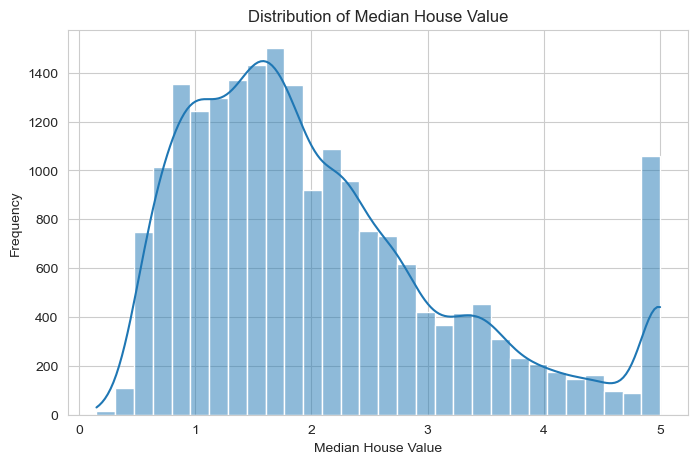

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### Histogram Observation

The histogram shows the distribution of median house values in the dataset. Most neighborhoods have median house values between 1 and 2, as indicated by the tallest bars in the graph. The distribution appears fairly balanced, suggesting that house values are spread across different ranges. No major irregularities were observed in the distribution.


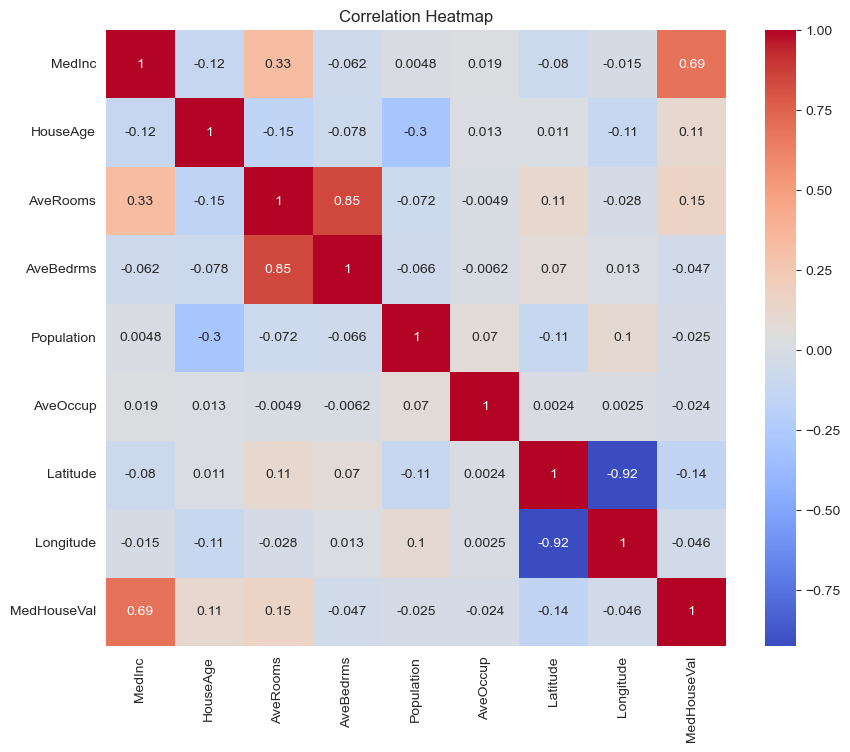

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap Observation

The heatmap shows the relationships between the variables in the dataset. MedInc has a strong positive correlation (0.69) with MedHouseVal, indicating that areas with higher median incomes tend to have higher house values. This suggests that median income is an important predictor of house prices.


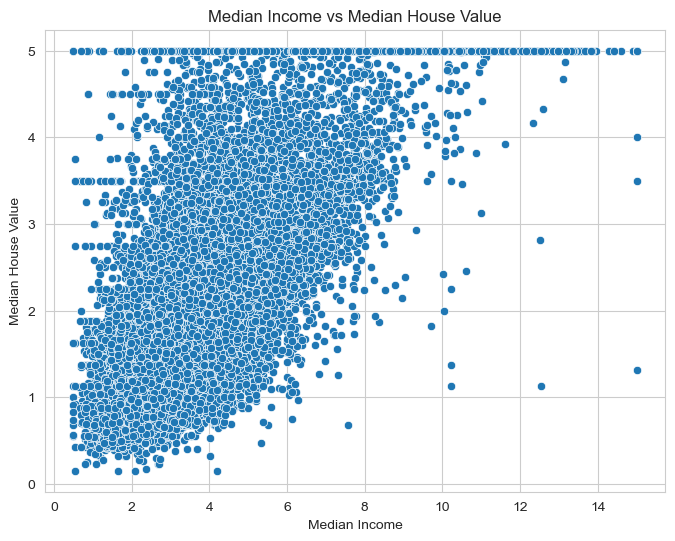

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

### Scatter Plot Observation

The scatter plot shows a positive relationship between Median Income (MedInc) and Median House Value (MedHouseVal). The points generally slope upward from left to right, indicating that house values tend to increase as median income increases. The pattern is relatively tight, which supports the strong positive correlation observed in the heatmap.


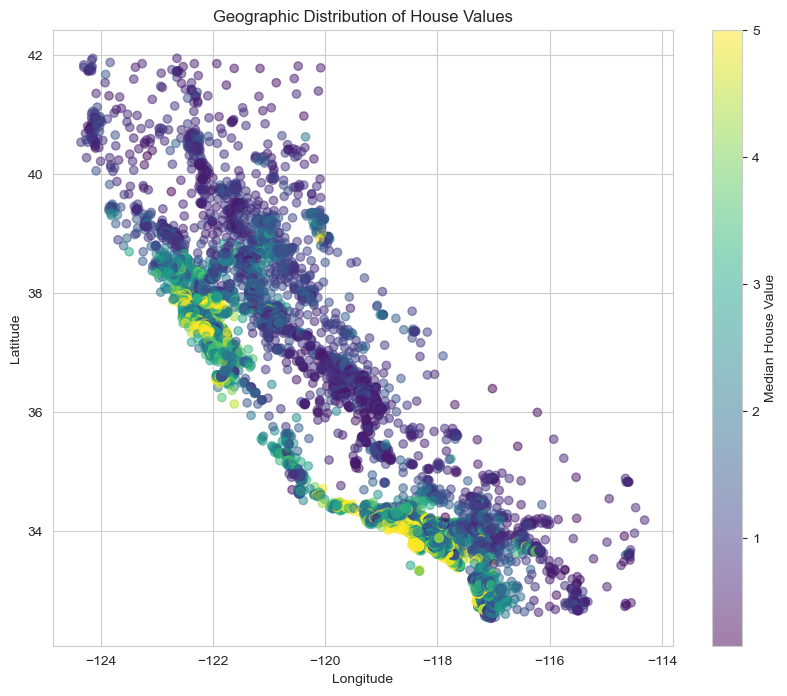

In [66]:
plt.figure(figsize=(10,8))


scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter,label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of House Values')
plt.show()


### Geographic Scatter Plot Observation

The geographic scatter plot shows the distribution of houses across different locations in California using latitude and longitude coordinates. Different colors represent different median house values. The points form a map-like pattern, and the variation in colors suggests that house values differ across locations. This indicates that geographic location may influence house prices.

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [68]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42

)

In [70]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaler = scaler.transform(X_test)

### A3 Data Preparation Observation

The dataset was split into training and testing sets in an 80:20 ratio, with the target variable (MedHouseVal) separated from the input features. Feature scaling was then applied using StandardScaler to bring all features onto a comparable scale. To avoid data leakage, the scaler was fitted only on the training data before being used to transform the test set.


In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [72]:
import sklearn

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
LinearRegression

sklearn.linear_model._base.LinearRegression

In [75]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

In [ ]:
lr_pred = lr_model.predict(X_test_scaler)

rf_pred = rf_model.predict(X_test)

In [ ]:
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2:",lr_r2)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

### A5 Model Evaluation Observation

Both Linear Regression and Random Forest Regressor were assessed using MAE, MSE, RMSE, and R² metrics. Overall, the Random Forest model performed better than Linear Regression across all measures, showing smaller prediction errors and a stronger fit. It achieved an R² score of 0.8046, meaning it explains about 80.46% of the variation in house prices. Based on these results, Random Forest is the more effective model for this dataset.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)
    

### A6 Feature Importance Observation

The Random Forest model shows that Median Income (MedInc) is the strongest factor in predicting house prices, with an importance score of about 0.525. This means that neighborhoods with higher income levels are generally associated with higher house values. Other features like Average Occupancy, Latitude, and Longitude also play meaningful roles in the predictions. On the other hand, Population and Average Bedrooms have much smaller importance scores, suggesting they have less influence on the model’s results.


### PART B
Classification — Predicting Iris Flower Species

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

In [ ]:
iris = load_iris(as_frame=True)

df_iris = iris.frame

df_iris.head()

In [ ]:
df_iris.shape

In [ ]:
df_iris.dtypes

### B1 Dataset Inspection Observation

The Iris dataset contains 150 rows and 5 columns. Four columns represent numerical flower measurements (sepal length, sepal width, petal length, and petal width) stored as float64 values. The target column is stored as int64 and represents the iris flower species encoded as 0, 1, and 2.


In [ ]:
df_iris['target'].value_counts()

### B1 Class Balance Observation

The Iris dataset is evenly balanced, containing 50 samples for each of the three classes. This is advantageous for classification tasks because the model receives equal representation of each species during training, helping to minimize bias toward any single class.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_iris, hue='target')
plt.show()

### Pairplot Observation

From the pairplot, I noticed that the flowers are grouped into different coloured clusters. Some groups are clearly separated while others overlap a little. I also observed that some plots have a sloping pattern, which suggests there may be a relationship between some of the flower measurements.


In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_iris.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

### Heatmap Observation

From the heatmap, I noticed that most of the features have positive correlations with each other. The target appears to be more closely related to petal length and petal width than to some of the other features. I also observed a few negative correlation values, which suggest that some features move in opposite directions.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df_iris.drop('target', axis=1)
y = df_iris['target']

In [ ]:
X.shape, y.shape

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape, X_test.shape

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### B3 Data Preparation Observation
The dataset was divided into training and testing sets using an 80:20 ratio. This resulted in 120 samples for training and 30 samples
for training and 30 samples for testing. The feature values were then scaled using StandardScaler so that all measurements would be on
a similar scaler before training the classification models.

In [ ]:
from sklearn .linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

### B4 Model Training Observation

Three classification models were trained on the Iris dataset: Logistic Regression, Decision Tree, and Random Forest. All models trained successfully without errors and were ready to be evaluated using the test data.


In [ ]:
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

In [ ]:
log_pred = log_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

### B5 Accuracy Observation

All three classification models achieved an accuracy score of 1.0 on the test set. This means that each model correctly classified all the flowers in the testing data. The result suggests that the Iris dataset is highly separable and suitable for classification tasks.


In [ ]:
print("Logistic Regression")
print(classification_report(y_test,log_pred))

### Logistic Regression Classification Report Observation

The Logistic Regression model performed very well on the test data. The precision, recall, and F1-score were all 1.00 for the three flower species. This means the model correctly identified all classes without making any classification mistakes on the test set.


In [ ]:
print("Decision Tree")
print(classification_report(y_test,dt_pred))

### Decision Tree Classification Report Observation

The Decision Tree model classified all the test samples correctly. The precision, recall, and F1-score were all 1.00 across the three classes. Based on the results, the model was able to distinguish between the flower species without making any mistakes on the test set.


In [ ]:
print("Random Forest")
print(classification_report(y_test,rf_pred))

### Random Forest Classification Report Observation

The Random Forest model also achieved perfect performance on the test data. All classes recorded precision, recall, and F1-scores of 1.00. This shows that the model correctly identified every flower species in the test set.


In [ ]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)
            

### Confusion Matrix Observation

The confusion matrix shows that all test samples were classified correctly. The values appear only on the main diagonal, while the other cells contain zeros. This means the model did not confuse one flower species with another during prediction.


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
X_2d = df_iris[['sepal length (cm)', 'sepal width (cm)']]
y = df_iris['target']

In [ ]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf_2d = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_2d.fit(X_train_2d, y_train_2d)

In [ ]:
plt.figure(figsize=(8,6))

DecisionBoundaryDisplay.from_estimator(
    rf_2d,
    X_2d,
    alpha=0.3
)

sns.scatterplot(
    x=X_2d['sepal length (cm)'],
    y=X_2d['sepal width (cm)'],
    hue=y,
)

plt.title('Random Forest Decision Boundary')
plt.show()

### B6 Decision Boundary Observation

The decision boundary plot was divided into light blue, light green, and cream-coloured regions. The flower samples appeared as purple, black, and cream dots scattered across the graph. I noticed that the cream-coloured cluster was more separated from the others, while the remaining classes overlapped in some areas. There were also a few dots that appeared inside a different coloured region, showing that the boundaries between some classes were not completely distinct when only sepal length and sepal width were used. Overall, the model was still able to create visible regions for class separation.


### PART C: QUIZ

##### Q1. Which metric tells you the average prediction error in the same units as the target variable?

A. R² Score
B. Mean Squared Error (MSE)
C. Mean Absolute Error (MAE)
D. Root Mean Squared Error (RMSE)

The answer is C, because MAE measures the average absolute difference between predicted and actual values in the same units as the target variable.

##### Q2. An R² score of 0.82 on the test set means:

A. The model made errors on 82% of predictions

B. 82% of the variance in the target is explained by the model

C. The model is 82% accurate in classifying outcomes

D. The RMSE value is 0.18

Explanation: An R² value of 0.82 indicates that the model explains 82% of the variation in the target variable, while the remaining 18% is due to factors not captured by the model or random variation.



##### Q3. You fit a StandardScaler on the entire dataset before splitting into train and test sets. This is an example of:

A. Regularisation

B. Data leakage

C. Feature engineering

D. Cross-validation

The answer is Data leakage because scaling used the full dataset before the train-test split, 
causing information from the test set to leak into training.

##### Q4. Which of the following results most strongly suggests a model is overfitting?

A. Train R² = 0.65, Test R² = 0.63

B. Train R² = 0.78, Test R² = 0.76

C. Train R² = 0.99, Test R² = 0.61

D. Train R² = 0.50, Test R² = 0.52

The answer is C, because the model performs almost perfectly on the training data (0.99) but much worse on the test data (0.61).

##### Q5.Why does Random Forest generally outperform Linear Regression on the California Housing dataset?

A. It uses more memory and is therefore more accurate

B. It can capture non-linear relationships between features and the target

C. It does not require feature scaling and is therefore simpler

D. It always produces a lower MSE than any other algorithm

The answer is B because Random Forest performs better because it can learn complex, non-linear patterns in housing data that
Linear Regression cannot capture well.

##### Q6.Feature importance from a Random Forest measures:

A. The Pearson correlation coefficient between each feature and the target

B. The coefficient assigned to each feature during linear regression

C. How much each feature reduces impurity (weighted) across all trees in the forest

D. The rank order of features by their number of missing values

The answer is C because, a feature is more important if it reduces impurity more often across the trees in the forest.

##### Q7.Why is stratify=y recommended when splitting classification data into train and test sets?

A. It makes the split faster by reducing the number of comparisons

B. It ensures each class appears in both sets at the same proportion as the full dataset

C. It removes duplicate rows before splitting

D. It automatically scales the features before splitting

The correct answer is B, because stratify=y ensures that the class distribution in the train and test 
sets remains similar to the original dataset.

##### Q8.A fraud detection model has high precision but low recall for the "Fraud" class. This means:

A. It correctly identifies all fraud cases but also flags many legitimate transactions

B. It rarely flags a transaction as fraud, but when it does, it is usually right

C. It has an overall accuracy above 90%

D. It confuses fraud cases with each other but not with legitimate transactions

The answer is B, because the model makes few fraud predictions, but those predictions are usually correct,
resulting in high precision and low recall.

##### Q9.In a confusion matrix for a 3-class problem, what do the off-diagonal cells represent?

A. Correct predictions for each class

B. True negative counts

C. Cases where the model predicted the wrong class

D. The F1 score for each class

The answer is C because Off-diagonal cells represent misclassified instances where the model predicted the wrong class.

##### Q10.Decision Tree and Random Forest classifiers do NOT require feature scaling because:

A. They use cosine similarity rather than Euclidean distance

B. They partition data using threshold comparisons on feature values, not distance calculations

C. They are ensemble models and ensembles are immune to scale differences

D. They only work with normalised data and scale internally

The answer is B because Decision Trees and Random Forests use threshold-based splits rather than
distance calculations, so feature scaling is usually unnecessary.

##### Q11.Which evaluation metric is most appropriate when the dataset has a balanced class distribution?

A. Precision only

B. Recall only

C. Accuracy

D. Area Under the ROC Curve (AUC)

The answer is Accuracy because With balanced classes, accuracy provides a fair measure of model performance.

##### Q12.In the Iris pairplot, Iris setosa appears clearly separated from the other two species. What does this tell you about model performance?

A. The dataset is too small to draw any conclusions

B. Logistic Regression will fail to classify setosa correctly

C. Setosa is likely the easiest class to classify correctly, any reasonable model should handle it well

D. All four features are equally important for separating the three species

The answer is C because In the pairplot, Iris setosa is clearly separated from the other two species. This means its feature values are distinct,making it easy for a model to identify and classify correctly.


##### Q13. Explain the difference between regression and classification. Give one example of each from the real world.

Regression is used to predict continuous numerical values, while classification is used to predict categories or classes.

Regression Example: Predicting house prices based on factors such as income, location, and number of rooms.

Classification Example: Predicting the species of an iris flower based on sepal and petal measurements.